# 03_cs114_baselines.ipynb

Notebook này dùng để xây dựng các mô hình baseline cho đồ án **Intel Image Classification**.

Mục tiêu chính:

- Đọc lại các file split đã sinh ra từ `02_preprocessing.ipynb`.
- Trích xuất đặc trưng ảnh đơn giản.
- Huấn luyện một số mô hình machine learning cơ bản.
- So sánh kết quả trên validation set.
- Chọn baseline tốt nhất và đánh giá trên test set.
- Lưu metrics, confusion matrix, prediction và model tốt nhất.

> Phiên bản này được viết để chạy trên **Google Colab** trước. Sau này khi chuyển về cấu trúc project local, bạn chủ yếu chỉ cần sửa cell cấu hình đường dẫn.


In [ ]:

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import os

# ============================================================
# CHỈ CẦN SỬA DÒNG NÀY KHI ĐỔI MÔI TRƯỜNG CHẠY
# ============================================================
PROJECT_ROOT = Path("/content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project")

# Dữ liệu gốc
RAW_DIR = PROJECT_ROOT / "data" / "raw"

# File split sinh ra từ 02_preprocessing.ipynb
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"

# Output cho notebook baseline
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "cs114"
METRICS_DIR = OUTPUTS_DIR / "metrics"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
FEATURES_DIR = OUTPUTS_DIR / "features" / "cs114"

# Model lưu lại
MODELS_DIR = PROJECT_ROOT / "models" / "cs114"

# Tạo thư mục nếu chưa có
for d in [FIGURES_DIR, METRICS_DIR, PREDICTIONS_DIR, FEATURES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("METADATA_DIR:", METADATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("PREDICTIONS_DIR:", PREDICTIONS_DIR)
print("MODELS_DIR:", MODELS_DIR)


PROJECT_ROOT: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project
RAW_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw
SPLITS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/splits
METADATA_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/metadata
FIGURES_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114
METRICS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/metrics
PREDICTIONS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions
MODELS_DIR: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs114


In [ ]:
import sys
import subprocess
import importlib.util

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Đang cài {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"Đã có {package_name}")

install_if_missing("scikit-image", "skimage")
install_if_missing("joblib", "joblib")


Đã có scikit-image
Đã có joblib


In [ ]:
import json
import random
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from skimage.feature import hog

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


## Thiết lập seed và chế độ chạy

Mặc định notebook để `FAST_MODE=True` để bạn chạy thử nhanh trên Colab.

- `FAST_MODE=True`: chỉ lấy một phần dữ liệu train/val để kiểm tra pipeline nhanh.
- `FAST_MODE=False`: chạy đầy đủ dữ liệu để lấy kết quả chính thức cho báo cáo.

Khi chạy chính thức, nên đổi:

```python
FAST_MODE = False
```


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Chạy thử nhanh trên Colab
FAST_MODE = False

# Nếu FAST_MODE=True thì giới hạn số mẫu để chạy nhanh
MAX_TRAIN_SAMPLES = 5000 if FAST_MODE else None
MAX_VAL_SAMPLES = 1500 if FAST_MODE else None

# Test thường chỉ chạy sau khi đã chọn model tốt nhất
# Có thể để None để đánh giá toàn bộ test set
MAX_TEST_SAMPLES = None

print("FAST_MODE:", FAST_MODE)
print("MAX_TRAIN_SAMPLES:", MAX_TRAIN_SAMPLES)
print("MAX_VAL_SAMPLES:", MAX_VAL_SAMPLES)
print("MAX_TEST_SAMPLES:", MAX_TEST_SAMPLES)


FAST_MODE: False
MAX_TRAIN_SAMPLES: None
MAX_VAL_SAMPLES: None
MAX_TEST_SAMPLES: None


## Đọc các file split từ preprocessing

Notebook này chạy với điều kiện chạy xong `02_preprocessing.ipynb` và đã có các file:

```text
data/splits/train.csv
data/splits/val.csv
data/splits/test.csv
data/splits/pred.csv
data/metadata/class_to_idx.json
```


In [ ]:
train_csv = SPLITS_DIR / "train.csv"
val_csv = SPLITS_DIR / "val.csv"
test_csv = SPLITS_DIR / "test.csv"
pred_csv = SPLITS_DIR / "pred.csv"
class_to_idx_path = METADATA_DIR / "class_to_idx.json"

required_files = [train_csv, val_csv, test_csv, class_to_idx_path]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {f}")

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

if pred_csv.exists():
    pred_df = pd.read_csv(pred_csv)
else:
    pred_df = None

with open(class_to_idx_path, "r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

# Đảm bảo key label_idx là int
idx_to_class = {int(v): k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)
print("Pred :", None if pred_df is None else pred_df.shape)
print("class_to_idx:", class_to_idx)
print("class_names:", class_names)

display(train_df.head())


Train: (11212, 11)
Val  : (2804, 11)
Test : (3000, 10)
Pred : (7301, 10)
class_to_idx: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


,split,label,file_name,relative_path,width,height,mode,error,file_hash,leaks_to_test,label_idx
0,train,street,168.jpg,seg_train/street/168.jpg,150,150,RGB,NaN,51030257c09363fa575fb06b84cde125,False,5
1,train,forest,2284.jpg,seg_train/forest/2284.jpg,150,150,RGB,NaN,ffd17580e011fc4e4cb28b052efe7b67,False,1
2,train,glacier,19429.jpg,seg_train/glacier/19429.jpg,150,150,RGB,NaN,6f5694ce122ddc043681ee12b79e7f4a,False,2
3,train,mountain,7979.jpg,seg_train/mountain/7979.jpg,150,150,RGB,NaN,6461b2a381a081a4366baea8f534589b,False,3
4,train,street,1146.jpg,seg_train/street/1146.jpg,150,150,RGB,NaN,c64f7683c5edca396427bbf31714d43f,False,5


## Kiểm tra cột dữ liệu

Các file split cần có ít nhất:

- `relative_path`
- `label`
- `label_idx`

`relative_path` sẽ được ghép với `RAW_DIR` để tìm ảnh gốc.


In [ ]:
required_columns = {"relative_path", "label", "label_idx"}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name}.csv thiếu các cột: {missing}")
    print(f"{name}.csv OK:", list(df.columns))


train.csv OK: ['split', 'label', 'file_name', 'relative_path', 'width', 'height', 'mode', 'error', 'file_hash', 'leaks_to_test', 'label_idx']
val.csv OK: ['split', 'label', 'file_name', 'relative_path', 'width', 'height', 'mode', 'error', 'file_hash', 'leaks_to_test', 'label_idx']
test.csv OK: ['split', 'label', 'file_name', 'relative_path', 'width', 'height', 'mode', 'error', 'file_hash', 'label_idx']


## Lấy mẫu dữ liệu khi chạy thử

Để chạy nhanh trên Colab, ta có thể lấy mẫu theo kiểu stratified sampling, tức là vẫn giữ tương đối phân bố lớp.

Khi `FAST_MODE=False`, cell này sẽ dùng toàn bộ dữ liệu.


In [ ]:
def stratified_sample_df(df, max_samples=None, label_col="label_idx", random_state=42):
    if max_samples is None or len(df) <= max_samples:
        return df.reset_index(drop=True)

    sampled_parts = []
    n_classes = df[label_col].nunique()

    for label_idx, group in df.groupby(label_col):
        frac = len(group) / len(df)
        n_take = max(1, int(round(frac * max_samples)))
        n_take = min(n_take, len(group))
        sampled_parts.append(group.sample(n=n_take, random_state=random_state))

    sampled_df = pd.concat(sampled_parts, axis=0)

    # Nếu do làm tròn mà vượt quá max_samples, lấy lại đúng số lượng
    if len(sampled_df) > max_samples:
        sampled_df = sampled_df.sample(n=max_samples, random_state=random_state)

    return sampled_df.sample(frac=1, random_state=random_state).reset_index(drop=True)


train_work_df = stratified_sample_df(train_df, MAX_TRAIN_SAMPLES, random_state=SEED)
val_work_df = stratified_sample_df(val_df, MAX_VAL_SAMPLES, random_state=SEED)
test_work_df = stratified_sample_df(test_df, MAX_TEST_SAMPLES, random_state=SEED)

print("Train dùng để chạy:", train_work_df.shape)
print("Val dùng để chạy  :", val_work_df.shape)
print("Test dùng để chạy :", test_work_df.shape)

display(train_work_df["label"].value_counts().sort_index())
display(val_work_df["label"].value_counts().sort_index())


Train dùng để chạy: (11212, 11)
Val dùng để chạy  : (2804, 11)
Test dùng để chạy : (3000, 10)


,count
label,
buildings,1752
forest,1815
glacier,1923
mountain,2004
sea,1817
street,1901


,count
label,
buildings,438
forest,454
glacier,481
mountain,501
sea,455
street,475


## Hàm xử lý đường dẫn ảnh

Trong preprocessing, ta lưu `relative_path` thay vì lưu đường dẫn tuyệt đối.  
Hàm dưới giúp tìm ảnh thật từ `RAW_DIR`.

Hàm này cũng xử lý được vài trường hợp `relative_path` có dạng khác nhau, ví dụ:

```text
seg_train/buildings/xxx.jpg
data/raw/seg_train/buildings/xxx.jpg
D:/.../seg_train/buildings/xxx.jpg
```


In [ ]:
def resolve_image_path(relative_path):
    p = Path(str(relative_path))

    # Nếu là đường dẫn tuyệt đối thì dùng luôn
    if p.is_absolute():
        return p

    # Nếu relative_path đã bắt đầu bằng data/raw thì ghép với PROJECT_ROOT
    parts = p.parts
    if len(parts) >= 2 and parts[0] == "data" and parts[1] == "raw":
        return PROJECT_ROOT / p

    # Trường hợp phổ biến: seg_train/..., seg_test/..., seg_pred/...
    return RAW_DIR / p


# Test nhanh vài ảnh đầu
for rel in train_work_df["relative_path"].head(5):
    img_path = resolve_image_path(rel)
    print(rel, "=>", img_path, "| exists:", img_path.exists())


seg_train/street/168.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/street/168.jpg | exists: True
seg_train/forest/2284.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/forest/2284.jpg | exists: True
seg_train/glacier/19429.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/glacier/19429.jpg | exists: True
seg_train/mountain/7979.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/mountain/7979.jpg | exists: True
seg_train/street/1146.jpg => /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_train/street/1146.jpg | exists: True


## Trích xuất đặc trưng ảnh

Ta sẽ thử 3 nhóm đặc trưng đơn giản:

### 1. Flatten pixel

Resize ảnh về kích thước nhỏ, chuẩn hóa về `[0, 1]`, rồi duỗi thành vector.

Ưu điểm:

- Dễ hiểu.
- Là baseline đơn giản nhất.

Nhược điểm:

- Vector khá dài.
- Không mô tả tốt cấu trúc ảnh.

### 2. Color histogram

Tính histogram màu cho từng kênh R, G, B.

Ưu điểm:

- Nhanh.
- Phù hợp với dữ liệu cảnh vì mỗi lớp có màu sắc đặc trưng, ví dụ `forest`, `sea`, `glacier`.

Nhược điểm:

- Không giữ thông tin hình dạng hay bố cục.

### 3. HOG

HOG mô tả hướng cạnh và cấu trúc cục bộ trong ảnh.

Ưu điểm:

- Tốt hơn flatten/color histogram trong việc mô tả hình dạng.
- Phù hợp với baseline truyền thống trước khi dùng CNN.

Nhược điểm:

- Chậm hơn color histogram.


In [ ]:
# Kích thước ảnh cho từng loại feature
FLATTEN_SIZE = (32, 32)
HIST_SIZE = (64, 64)
HOG_SIZE = (64, 64)

# Số bin histogram cho mỗi kênh màu
HIST_BINS = 16


def load_rgb_image(image_path, size):
    """Đọc ảnh RGB, resize và đưa về numpy array trong khoảng [0, 1]."""
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


def extract_flatten_feature(image_path):
    """Feature 1: resize ảnh rồi flatten pixel RGB."""
    arr = load_rgb_image(image_path, FLATTEN_SIZE)
    return arr.reshape(-1).astype(np.float32)


def extract_color_hist_feature(image_path):
    """Feature 2: histogram màu RGB."""
    arr = load_rgb_image(image_path, HIST_SIZE)
    features = []

    for c in range(3):
        hist, _ = np.histogram(
            arr[:, :, c],
            bins=HIST_BINS,
            range=(0.0, 1.0),
            density=True
        )
        features.append(hist)

    return np.concatenate(features).astype(np.float32)


def rgb_to_gray(arr):
    """Chuyển ảnh RGB [0,1] sang grayscale."""
    return 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]


def extract_hog_feature(image_path):
    """Feature 3: HOG trên ảnh grayscale."""
    arr = load_rgb_image(image_path, HOG_SIZE)
    gray = rgb_to_gray(arr)

    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    return feat.astype(np.float32)


FEATURE_EXTRACTORS = {
    "flatten": extract_flatten_feature,
    "color_hist": extract_color_hist_feature,
    "hog": extract_hog_feature
}

# Kiểm tra kích thước vector feature trên một ảnh
sample_img_path = resolve_image_path(train_work_df.iloc[0]["relative_path"])

for feature_name, extractor in FEATURE_EXTRACTORS.items():
    feat = extractor(sample_img_path)
    print(feature_name, "shape:", feat.shape)


flatten shape: (3072,)
color_hist shape: (48,)
hog shape: (1764,)


## Hàm extract feature cho toàn bộ split

Để tiết kiệm thời gian, feature sẽ được cache vào:

```text
outputs/features/cs114/
```

Nếu chạy lại notebook, hệ thống sẽ đọc cache nếu file đã tồn tại.

Nếu bạn đổi `FAST_MODE`, đổi số mẫu, hoặc đổi logic feature, nên xóa thư mục cache hoặc đổi tên cache.


In [ ]:
def extract_features_from_df(df, feature_type, split_name):
    """Extract feature cho một dataframe split."""
    if feature_type not in FEATURE_EXTRACTORS:
        raise ValueError(f"feature_type không hợp lệ: {feature_type}")

    extractor = FEATURE_EXTRACTORS[feature_type]
    X = []
    used_indices = []
    errors = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"{split_name} - {feature_type}"):
        img_path = resolve_image_path(row["relative_path"])

        try:
            feat = extractor(img_path)
            X.append(feat)
            used_indices.append(i)
        except Exception as e:
            errors.append({
                "index": i,
                "relative_path": row["relative_path"],
                "error": str(e)
            })

    if len(X) == 0:
        raise RuntimeError(f"Không extract được feature nào cho {split_name} - {feature_type}")

    X = np.vstack(X).astype(np.float32)
    used_df = df.iloc[used_indices].reset_index(drop=True).copy()
    y = used_df["label_idx"].astype(int).values

    if errors:
        error_df = pd.DataFrame(errors)
        error_path = METADATA_DIR / f"errors_{split_name}_{feature_type}.csv"
        error_df.to_csv(error_path, index=False)
        print(f"Có {len(errors)} lỗi. Đã lưu tại: {error_path}")

    return X, y, used_df


def feature_cache_path(split_name, feature_type, df):
    mode = "fast" if FAST_MODE else "full"
    return FEATURES_DIR / f"{split_name}_{feature_type}_{mode}_n{len(df)}.npz"


def get_features(df, feature_type, split_name, use_cache=True):
    """Lấy feature từ cache nếu có, nếu không thì extract và lưu cache."""
    cache_path = feature_cache_path(split_name, feature_type, df)

    if use_cache and cache_path.exists():
        data = np.load(cache_path, allow_pickle=True)
        X = data["X"]
        y = data["y"]
        used_indices = data["used_indices"]
        used_df = df.iloc[used_indices].reset_index(drop=True).copy()
        print(f"Đã load cache: {cache_path}")
        return X, y, used_df

    X, y, used_df = extract_features_from_df(df, feature_type, split_name)

    used_indices = used_df.index.values
    np.savez_compressed(
        cache_path,
        X=X,
        y=y,
        used_indices=used_indices
    )
    print(f"Đã lưu cache: {cache_path}")

    return X, y, used_df


## Định nghĩa các mô hình baseline

Ta sẽ thử các baseline sau:

| Tên thí nghiệm | Feature | Model |
|---|---|---|
| `flatten_logistic_regression` | Flatten pixel | Logistic Regression |
| `color_hist_knn` | Color Histogram | KNN |
| `color_hist_logistic_regression` | Color Histogram | Logistic Regression |
| `hog_linear_svm` | HOG | Linear SVM |
| `hog_logistic_regression` | HOG | Logistic Regression |

Các mô hình đều là baseline truyền thống, phù hợp với phần CS114.


In [ ]:
experiments = [
    {
        "name": "flatten_logistic_regression",
        "feature_type": "flatten",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=SEED
            ))
        ])
    },
    {
        "name": "color_hist_knn",
        "feature_type": "color_hist",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=5,
                weights="distance",
                n_jobs=-1
            ))
        ])
    },
    {
        "name": "color_hist_logistic_regression",
        "feature_type": "color_hist",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=SEED
            ))
        ])
    },
    {
        "name": "hog_linear_svm",
        "feature_type": "hog",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                class_weight="balanced",
                max_iter=5000,
                dual=False,
                random_state=SEED
            ))
        ])
    },
    {
        "name": "hog_logistic_regression",
        "feature_type": "hog",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                n_jobs=-1,
                random_state=SEED
            ))
        ])
    }
]

print("Số thí nghiệm:", len(experiments))
for exp in experiments:
    print("-", exp["name"], "| feature:", exp["feature_type"])


Số thí nghiệm: 5
- flatten_logistic_regression | feature: flatten
- color_hist_knn | feature: color_hist
- color_hist_logistic_regression | feature: color_hist
- hog_linear_svm | feature: hog
- hog_logistic_regression | feature: hog


## Hàm đánh giá mô hình

Ta dùng các metric:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

Trong bài toán nhiều lớp và dữ liệu không hoàn toàn đều nhau, **macro F1** là chỉ số nên xem kỹ vì nó đánh giá trung bình theo từng lớp.


In [ ]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1
    }


def print_classification_report(y_true, y_pred, title="Classification Report"):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))


## Chạy các baseline trên validation set

Quy trình:

1. Extract feature cho train và validation.
2. Train model trên train.
3. Dự đoán trên validation.
4. Lưu metric.
5. Chọn model tốt nhất theo `macro_f1`.

Cell này có thể chạy hơi lâu nếu `FAST_MODE=False`, đặc biệt là phần HOG.


In [ ]:
results = []
trained_models = {}
feature_data = {}

for exp in experiments:
    exp_name = exp["name"]
    feature_type = exp["feature_type"]
    model = exp["model"]

    print("\n" + "=" * 100)
    print(f"Đang chạy thí nghiệm: {exp_name}")
    print(f"Feature type: {feature_type}")
    print("=" * 100)

    # Load hoặc extract feature
    if feature_type not in feature_data:
        X_train, y_train, used_train_df = get_features(train_work_df, feature_type, "train")
        X_val, y_val, used_val_df = get_features(val_work_df, feature_type, "val")
        feature_data[feature_type] = {
            "X_train": X_train,
            "y_train": y_train,
            "used_train_df": used_train_df,
            "X_val": X_val,
            "y_val": y_val,
            "used_val_df": used_val_df
        }
    else:
        X_train = feature_data[feature_type]["X_train"]
        y_train = feature_data[feature_type]["y_train"]
        X_val = feature_data[feature_type]["X_val"]
        y_val = feature_data[feature_type]["y_val"]
        used_train_df = feature_data[feature_type]["used_train_df"]
        used_val_df = feature_data[feature_type]["used_val_df"]

    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)

    # Train
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predict validation
    start_time = time.time()
    y_val_pred = model.predict(X_val)
    val_predict_time = time.time() - start_time

    # Metrics
    metrics = compute_metrics(y_val, y_val_pred)

    row = {
        "experiment": exp_name,
        "feature_type": feature_type,
        "n_train": len(y_train),
        "n_val": len(y_val),
        "n_features": X_train.shape[1],
        "train_time_sec": train_time,
        "val_predict_time_sec": val_predict_time,
        **metrics
    }

    results.append(row)
    trained_models[exp_name] = {
        "model": model,
        "feature_type": feature_type,
        "metrics": metrics
    }

    print(f"Train time: {train_time:.2f} sec")
    print(f"Val accuracy: {metrics['accuracy']:.4f}")
    print(f"Val macro F1: {metrics['macro_f1']:.4f}")
    print_classification_report(y_val, y_val_pred, title=f"Validation report - {exp_name}")


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

metrics_path = METRICS_DIR / "cs114_baselines_metrics.csv"
results_df.to_csv(metrics_path, index=False)

print("\nĐã lưu metrics tại:", metrics_path)
display(results_df)



Đang chạy thí nghiệm: flatten_logistic_regression
Feature type: flatten


train - flatten:   0%|          | 0/11212 [00:00<?, ?it/s]

Đã lưu cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/train_flatten_full_n11212.npz


val - flatten:   0%|          | 0/2804 [00:00<?, ?it/s]

Đã lưu cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/val_flatten_full_n2804.npz
X_train: (11212, 3072)
X_val  : (2804, 3072)
Train time: 121.22 sec
Val accuracy: 0.4444
Val macro F1: 0.4423
Validation report - flatten_logistic_regression
              precision    recall  f1-score   support

   buildings       0.28      0.27      0.27       438
      forest       0.68      0.69      0.69       454
     glacier       0.46      0.50      0.48       481
    mountain       0.45      0.45      0.45       501
         sea       0.26      0.27      0.26       455
      street       0.53      0.47      0.50       475

    accuracy                           0.44      2804
   macro avg       0.44      0.44      0.44      2804
weighted avg       0.44      0.44      0.44      2804


Đang chạy thí nghiệm: color_hist_knn
Feature type: color_hist


...

train - hog:   0%|          | 0/11212 [00:00<?, ?it/s]

Đã lưu cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/train_hog_full_n11212.npz


val - hog:   0%|          | 0/2804 [00:00<?, ?it/s]

Đã lưu cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/val_hog_full_n2804.npz
X_train: (11212, 1764)
X_val  : (2804, 1764)
Train time: 139.59 sec
Val accuracy: 0.5685
Val macro F1: 0.5707
Validation report - hog_linear_svm
              precision    recall  f1-score   support

   buildings       0.60      0.60      0.60       438
      forest       0.79      0.82      0.81       454
     glacier       0.43      0.44      0.44       481
    mountain       0.43      0.41      0.42       501
         sea       0.51      0.51      0.51       455
      street       0.66      0.65      0.65       475

    accuracy                           0.57      2804
   macro avg       0.57      0.57      0.57      2804
weighted avg       0.57      0.57      0.57      2804


Đang chạy thí nghiệm: hog_logistic_regression
Feature type: hog
X_train: (11212, 1764)
X_val  : (2804, 1764)
Train time: 46.54 sec
Val accuracy: 0.5838
Val macro F

,experiment,feature_type,n_train,n_val,n_features,train_time_sec,val_predict_time_sec,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,hog_logistic_regression,hog,11212,2804,1764,46.544727,0.029237,0.583809,0.585926,0.587629,0.586621,0.581928,0.583809,0.582714
1,hog_linear_svm,hog,11212,2804,1764,139.587509,0.040914,0.568474,0.569587,0.572094,0.570721,0.566402,0.568474,0.567316
2,color_hist_logistic_regression,color_hist,11212,2804,48,1.522811,0.002387,0.489301,0.475712,0.488016,0.476005,0.476414,0.489301,0.476937
3,color_hist_knn,color_hist,11212,2804,48,0.010341,0.282913,0.472896,0.454295,0.472388,0.451858,0.456265,0.472896,0.453045
4,flatten_logistic_regression,flatten,11212,2804,3072,121.223986,0.052729,0.444365,0.443120,0.442481,0.442307,0.444872,0.444365,0.444119


## Vẽ biểu đồ so sánh baseline

Biểu đồ này giúp nhìn nhanh mô hình nào tốt hơn trên validation set.


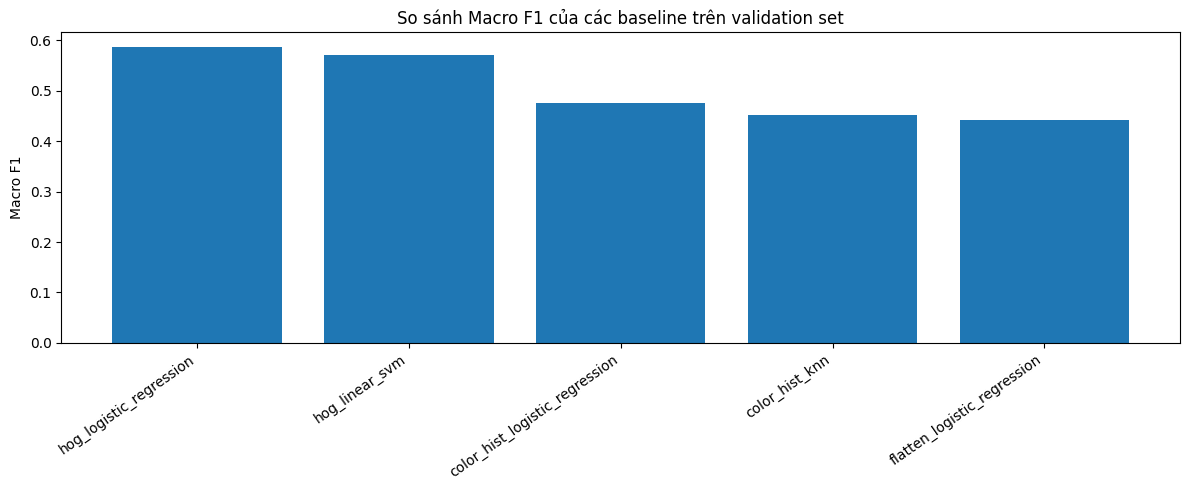

Đã lưu biểu đồ tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/baseline_macro_f1_comparison.png


In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["macro_f1"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Macro F1")
plt.title("So sánh Macro F1 của các baseline trên validation set")
plt.tight_layout()

baseline_compare_path = FIGURES_DIR / "baseline_macro_f1_comparison.png"
plt.savefig(baseline_compare_path, dpi=150)
plt.show()

print("Đã lưu biểu đồ tại:", baseline_compare_path)


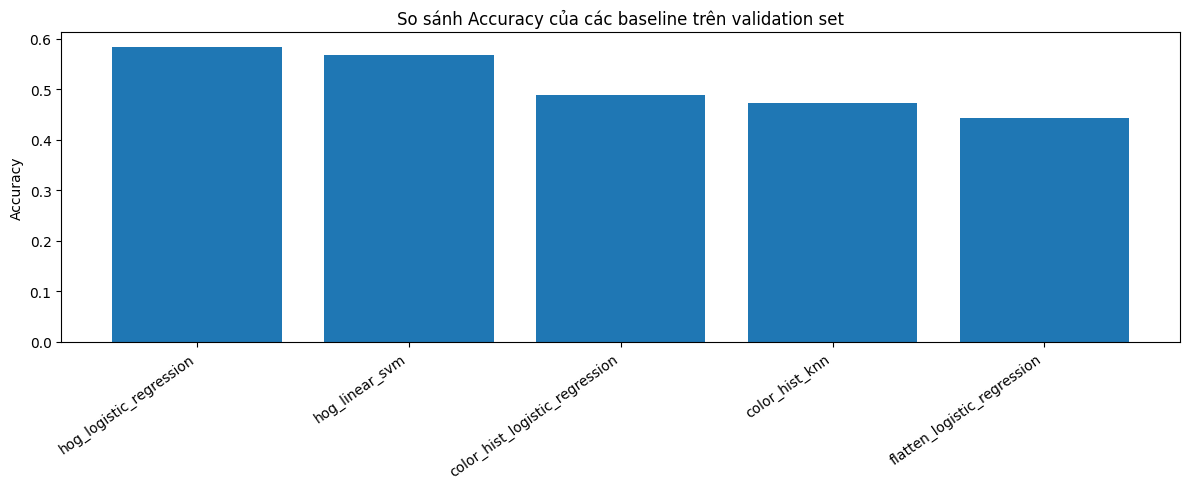

Đã lưu biểu đồ tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/baseline_accuracy_comparison.png


In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(results_df["experiment"], results_df["accuracy"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Accuracy")
plt.title("So sánh Accuracy của các baseline trên validation set")
plt.tight_layout()

accuracy_compare_path = FIGURES_DIR / "baseline_accuracy_comparison.png"
plt.savefig(accuracy_compare_path, dpi=150)
plt.show()

print("Đã lưu biểu đồ tại:", accuracy_compare_path)

## Chọn baseline tốt nhất

Ta chọn model tốt nhất theo `macro_f1` trên validation set.

Lý do dùng `macro_f1`:

- Mỗi lớp đều được xem trọng như nhau.
- Phù hợp khi muốn đánh giá mô hình có học tốt tất cả các lớp hay không.


In [ ]:
best_row = results_df.iloc[0]
best_exp_name = best_row["experiment"]
best_feature_type = best_row["feature_type"]

best_model = trained_models[best_exp_name]["model"]

print("Best experiment:", best_exp_name)
print("Best feature type:", best_feature_type)
print("Validation accuracy:", best_row["accuracy"])
print("Validation macro F1:", best_row["macro_f1"])


Best experiment: hog_logistic_regression
Best feature type: hog
Validation accuracy: 0.583808844507846
Validation macro F1: 0.5866214867075333


## Đánh giá model tốt nhất trên test set

Sau khi đã chọn model dựa trên validation set, ta đánh giá một lần trên test set.

Lưu ý:

- Không dùng test set để chọn model.
- Test set chỉ dùng để báo cáo kết quả cuối của baseline tốt nhất.


In [ ]:
X_test, y_test, used_test_df = get_features(test_work_df, best_feature_type, "test")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

start_time = time.time()
y_test_pred = best_model.predict(X_test)
test_predict_time = time.time() - start_time

test_metrics = compute_metrics(y_test, y_test_pred)

print("Test predict time:", round(test_predict_time, 2), "sec")
print("Test metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

print_classification_report(y_test, y_test_pred, title=f"Test report - {best_exp_name}")


test - hog:   0%|          | 0/3000 [00:00<?, ?it/s]

Đã lưu cache: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/features/cs114/test_hog_full_n3000.npz
X_test: (3000, 1764)
y_test: (3000,)
Test predict time: 0.05 sec
Test metrics:
accuracy: 0.5937
macro_precision: 0.5964
macro_recall: 0.5996
macro_f1: 0.5978
weighted_precision: 0.5911
weighted_recall: 0.5937
weighted_f1: 0.5923
Test report - hog_logistic_regression
              precision    recall  f1-score   support

   buildings       0.63      0.64      0.64       437
      forest       0.78      0.82      0.80       474
     glacier       0.51      0.51      0.51       553
    mountain       0.46      0.46      0.46       525
         sea       0.51      0.48      0.49       510
      street       0.68      0.68      0.68       501

    accuracy                           0.59      3000
   macro avg       0.60      0.60      0.60      3000
weighted avg       0.59      0.59      0.59      3000



## Lưu kết quả test prediction

File prediction sẽ gồm:

- `relative_path`
- `true_label`
- `true_label_idx`
- `pred_label`
- `pred_label_idx`
- `is_correct`

File này sẽ rất hữu ích cho notebook `07_error_analysis.ipynb`.


In [ ]:
test_pred_df = used_test_df.copy()
test_pred_df["true_label_idx"] = y_test
test_pred_df["pred_label_idx"] = y_test_pred
test_pred_df["true_label"] = test_pred_df["true_label_idx"].map(idx_to_class)
test_pred_df["pred_label"] = test_pred_df["pred_label_idx"].map(idx_to_class)
test_pred_df["is_correct"] = test_pred_df["true_label_idx"] == test_pred_df["pred_label_idx"]

prediction_path = PREDICTIONS_DIR / "cs114_best_baseline_test_predictions.csv"
test_pred_df.to_csv(prediction_path, index=False)

print("Đã lưu prediction tại:", prediction_path)
display(test_pred_df.head())
print("Số dự đoán đúng:", test_pred_df["is_correct"].sum())
print("Tổng số ảnh test:", len(test_pred_df))


Đã lưu prediction tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/predictions/cs114_best_baseline_test_predictions.csv


,split,label,file_name,relative_path,width,height,mode,error,file_hash,label_idx,true_label_idx,pred_label_idx,true_label,pred_label,is_correct
0,test,buildings,20057.jpg,seg_test/buildings/20057.jpg,150,150,RGB,NaN,c05af5c7bcce817b4e03c89cf99523b3,0,0,1,buildings,forest,False
1,test,buildings,20060.jpg,seg_test/buildings/20060.jpg,150,150,RGB,NaN,294b7b292e7ba7d938b7819cde55125c,0,0,5,buildings,street,False
2,test,buildings,20061.jpg,seg_test/buildings/20061.jpg,150,150,RGB,NaN,1dc62bcc7c181f63d546cef3a108ac0e,0,0,0,buildings,buildings,True
3,test,buildings,20064.jpg,seg_test/buildings/20064.jpg,150,150,RGB,NaN,b1369f91a642bda82a51b041f97870a9,0,0,3,buildings,mountain,False
4,test,buildings,20073.jpg,seg_test/buildings/20073.jpg,150,150,RGB,NaN,3c520c75fde0970f78531d6fbaa334bb,0,0,2,buildings,glacier,False


Số dự đoán đúng: 1781
Tổng số ảnh test: 3000


## Confusion matrix

Confusion matrix giúp xem mô hình hay nhầm lớp nào với lớp nào.

Với dữ liệu Intel Image Classification, các cặp dễ nhầm thường có thể là:

- `glacier` và `mountain`
- `buildings` và `street`
- `sea` và `glacier`


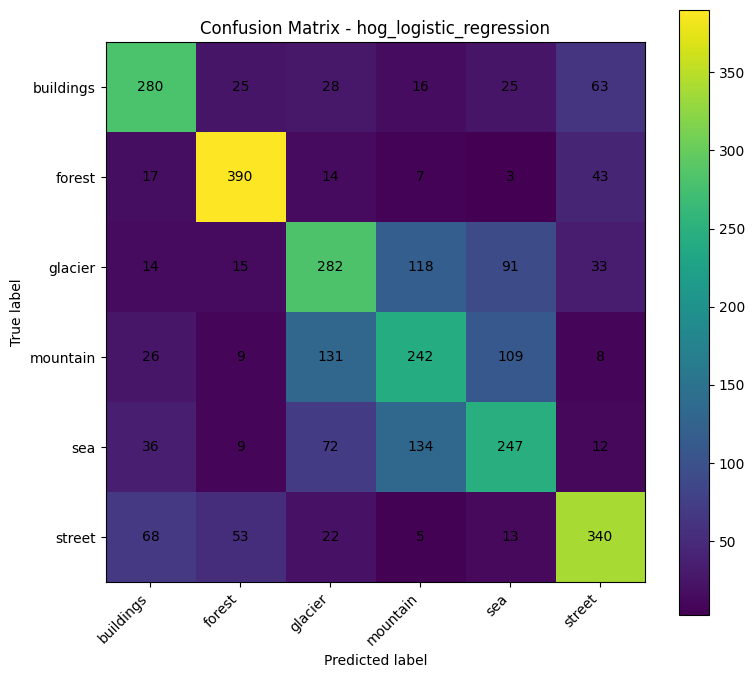

Đã lưu confusion matrix tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/outputs/figures/cs114/confusion_matrix_best_baseline.png


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_exp_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_path = FIGURES_DIR / "confusion_matrix_best_baseline.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print("Đã lưu confusion matrix tại:", cm_path)


## Lưu model baseline tốt nhất

Ta lưu model tốt nhất kèm thông tin feature extractor để sau này có thể load lại và dự đoán.


In [ ]:
best_package = {
    "model": best_model,
    "best_experiment": best_exp_name,
    "feature_type": best_feature_type,
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "class_names": class_names,
    "config": {
        "flatten_size": FLATTEN_SIZE,
        "hist_size": HIST_SIZE,
        "hog_size": HOG_SIZE,
        "hist_bins": HIST_BINS,
        "fast_mode": FAST_MODE,
        "seed": SEED
    },
    "validation_metrics": best_row.to_dict(),
    "test_metrics": test_metrics
}

model_path = MODELS_DIR / "best_baseline_model.joblib"
joblib.dump(best_package, model_path)

print("Đã lưu model tại:", model_path)


Đã lưu model tại: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/models/cs114/best_baseline_model.joblib


## Hàm dự đoán thử một ảnh

Cell này dùng để kiểm tra nhanh model đã lưu có thể dự đoán một ảnh bất kỳ hay không.


Ảnh: /content/drive/MyDrive/hk2 2025 - 2026/ CS231.Q22_Nhap_mon_thi_giac/intel_image_project/data/raw/seg_test/buildings/20094.jpg
Nhãn thật: buildings
Dự đoán: buildings


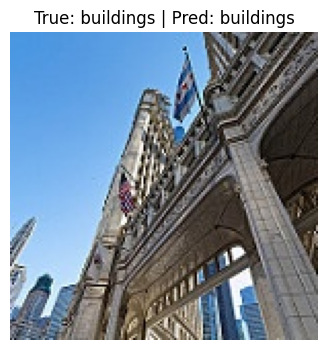

In [ ]:
def extract_feature_by_type(image_path, feature_type):
    if feature_type == "flatten":
        return extract_flatten_feature(image_path)
    elif feature_type == "color_hist":
        return extract_color_hist_feature(image_path)
    elif feature_type == "hog":
        return extract_hog_feature(image_path)
    else:
        raise ValueError(f"Feature type không hợp lệ: {feature_type}")


def predict_one_image(image_path, package):
    image_path = Path(image_path)
    feature_type = package["feature_type"]
    model = package["model"]
    idx_to_class = package["idx_to_class"]

    feat = extract_feature_by_type(image_path, feature_type)
    X = feat.reshape(1, -1)

    pred_idx = int(model.predict(X)[0])
    pred_label = idx_to_class[pred_idx]

    return pred_idx, pred_label


# Dự đoán thử một ảnh trong test set
sample_row = used_test_df.iloc[8]
sample_path = resolve_image_path(sample_row["relative_path"])

package = joblib.load(model_path)
pred_idx, pred_label = predict_one_image(sample_path, package)

print("Ảnh:", sample_path)
print("Nhãn thật:", sample_row["label"])
print("Dự đoán:", pred_label)

img = Image.open(sample_path).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"True: {sample_row['label']} | Pred: {pred_label}")
plt.show()


## Tổng kết kết quả baseline

Sau khi chạy xong notebook:

1. Đã dùng những feature nào. (những feature nào dùng cho mô hình nào )
2. Đã dùng những mô hình nào.
3. Model nào tốt nhất trên validation set. (này là bước so sánh sau cùng)
4. Kết quả cuối trên test set.
5. Các lớp nào bị nhầm nhiều dựa vào confusion matrix. (sau khi chạy xong 3 model)

Các file quan trọng được sinh ra:

```text
outputs/metrics/cs114_baselines_metrics.csv
outputs/figures/cs114/baseline_macro_f1_comparison.png
outputs/figures/cs114/confusion_matrix_best_baseline.png
outputs/predictions/cs114_best_baseline_test_predictions.csv
models/cs114/best_baseline_model.joblib
```


